https://colab.research.google.com/drive/1oJgqXxb8l3kVDloA1AS1ZVVw9NVcU72U

1. Import libraries

In [2]:
# Import required Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

This cell imports Pandas for data handling, NumPy for numerical processing, and Matplotlib for visualisation.

2. Load datasets from GitHub

In [3]:
# Base GitHub raw URL
base_url = "https://raw.githubusercontent.com/maazmohammed626-ctrl/northstar-database-analytics/refs/heads/main/northstar_dataset/"

# Load NorthStar datasets
orders = pd.read_csv(base_url + "orders.csv")
deliveries = pd.read_csv(base_url + "deliveries.csv")
complaints = pd.read_csv(base_url + "complaints.csv")
customers = pd.read_csv(base_url + "customers.csv")
drivers = pd.read_csv(base_url + "drivers.csv")
vehicles = pd.read_csv(base_url + "vehicles.csv")
incidents = pd.read_csv(base_url + "incidents.csv")
app_events = pd.read_csv(base_url + "app_events.csv")
hubs = pd.read_csv(base_url + "hubs.csv")

This loads all datasets directly from GitHub so the notebook is reproducible and connected to the submitted repository.

3. Check dataset sizes

In [4]:
# Check number of rows and columns in each dataset
datasets = {
    "orders": orders,
    "deliveries": deliveries,
    "complaints": complaints,
    "customers": customers,
    "drivers": drivers,
    "vehicles": vehicles,
    "incidents": incidents,
    "app_events": app_events,
    "hubs": hubs
}

for name, df in datasets.items():
    print(name, df.shape)

orders (1250, 11)
deliveries (950, 13)
complaints (320, 10)
customers (650, 9)
drivers (170, 8)
vehicles (120, 8)
incidents (280, 7)
app_events (640, 10)
hubs (8, 5)


This gives an overview of dataset size and helps understand how much data is available for analysis.

4. Check missing values

In [5]:
# Check missing values in each dataset
for name, df in datasets.items():
    print("\nMissing values in", name)
    print(df.isnull().sum())


Missing values in orders
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

Missing values in deliveries
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64

Missing values in complaints
complaint_id            0
customer_id             0
order_id                0
complaint_type          0
channel 

This identifies missing values across the datasets. This is important because incomplete records can affect analysis accuracy.

5. Clean categorical text values

In [6]:
# Function to clean text columns by removing spaces and making values consistent
def clean_text_columns(df):
    df_clean = df.copy()
    for col in df_clean.select_dtypes(include="object").columns:
        df_clean[col] = df_clean[col].astype(str).str.strip().str.lower()
    return df_clean

# Apply cleaning to relevant datasets
orders_clean = clean_text_columns(orders)
deliveries_clean = clean_text_columns(deliveries)
complaints_clean = clean_text_columns(complaints)
customers_clean = clean_text_columns(customers)
drivers_clean = clean_text_columns(drivers)
vehicles_clean = clean_text_columns(vehicles)
incidents_clean = clean_text_columns(incidents)
app_events_clean = clean_text_columns(app_events)
hubs_clean = clean_text_columns(hubs)

This standardises text values so categories are more consistent. For example, values with different capital letters or extra spaces are treated the same.

6. Handle missing numerical values

In [7]:
# Fill missing numeric values using median values
for df in [orders_clean, deliveries_clean, complaints_clean, customers_clean, drivers_clean, vehicles_clean, incidents_clean, app_events_clean, hubs_clean]:
    numeric_cols = df.select_dtypes(include=np.number).columns
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())

Missing numerical values are filled using the median because it is less affected by extreme values than the mean.

7. Create delivery risk feature

In [8]:
# Create a risk flag for deliveries with poor rating, route overrides, or non-completed status
deliveries_clean["delivery_risk_flag"] = np.where(
    (deliveries_clean["customer_rating_post_delivery"] < 3) |
    (deliveries_clean["manual_route_override_count"] > 2) |
    (deliveries_clean["delivery_status"] != "completed"),
    1,
    0
)

deliveries_clean[["delivery_id", "delivery_status", "customer_rating_post_delivery",
                  "manual_route_override_count", "delivery_risk_flag"]].head()

,delivery_id,delivery_status,customer_rating_post_delivery,manual_route_override_count,delivery_risk_flag
0,dl00001,failed,3.07,1,1
1,dl00002,ontime,5.00,1,1
2,dl00003,ontime,4.98,0,1
3,dl00004,delayed,4.18,0,1
4,dl00005,ontime,4.18,1,1


his creates a new feature to identify risky deliveries. A delivery is marked as risky if it has low rating, high route overrides, or was not completed.

8. Merge orders and deliveries

In [9]:
# Merge orders and deliveries using order_id
order_delivery = pd.merge(
    orders_clean,
    deliveries_clean,
    on="order_id",
    how="inner"
)

order_delivery.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_risk_flag
0,o00001,c0292,passenger,2024-08-20 14:43:00,6,airport,south,medium,126.65,app,...,h01,2024-08-20 16:29:00,2024-08-20 18:52:56.172161,ontime,26.65,2,0,4.29,15.82,1
1,o00003,c0161,passenger,2025-09-02 14:37:00,4,west,airport,high,33.50,phone,...,h02,2025-09-02 16:59:00,2025-09-03 01:50:39.644673,delayed,13.04,2,0,3.70,13.16,1
2,o00004,c0520,parcel,2025-01-11 17:15:00,2,riverside,north,medium,10.04,app,...,h02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,ontime,10.34,1,0,5.00,13.41,1
3,o00005,c0558,retail,2025-02-17 19:32:00,12,riverside,south,low,125.58,phone,...,h03,2025-02-17 20:23:00,2025-02-18 08:05:00.047082,ontime,16.01,1,0,4.38,13.53,1
4,o00007,c0001,business,2024-05-05 21:32:00,2,central,airport,low,76.12,app,...,h06,2024-05-05 22:10:00,2024-05-06 07:05:17.555250,delayed,9.07,1,1,3.93,9.76,1


This combines customer order records with delivery outcomes, allowing service demand to be linked with actual operational performance.

9. Add complaint information

In [10]:
# Count complaints for each order
complaint_summary = complaints_clean.groupby("order_id").agg(
    total_complaints=("complaint_id", "count"),
    avg_resolution_days=("resolution_days", "mean"),
    avg_compensation=("compensation_amount", "mean")
).reset_index()

# Merge complaint summary with order-delivery dataset
full_analysis = pd.merge(
    order_delivery,
    complaint_summary,
    on="order_id",
    how="left"
)

# Replace missing complaint values with 0
full_analysis["total_complaints"] = full_analysis["total_complaints"].fillna(0)
full_analysis["avg_resolution_days"] = full_analysis["avg_resolution_days"].fillna(0)
full_analysis["avg_compensation"] = full_analysis["avg_compensation"].fillna(0)

full_analysis.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_risk_flag,total_complaints,avg_resolution_days,avg_compensation
0,o00001,c0292,passenger,2024-08-20 14:43:00,6,airport,south,medium,126.65,app,...,ontime,26.65,2,0,4.29,15.82,1,0.0,0.0,0.00
1,o00003,c0161,passenger,2025-09-02 14:37:00,4,west,airport,high,33.50,phone,...,delayed,13.04,2,0,3.70,13.16,1,1.0,2.0,8.66
2,o00004,c0520,parcel,2025-01-11 17:15:00,2,riverside,north,medium,10.04,app,...,ontime,10.34,1,0,5.00,13.41,1,0.0,0.0,0.00
3,o00005,c0558,retail,2025-02-17 19:32:00,12,riverside,south,low,125.58,phone,...,ontime,16.01,1,0,4.38,13.53,1,1.0,8.0,54.41
4,o00007,c0001,business,2024-05-05 21:32:00,2,central,airport,low,76.12,app,...,delayed,9.07,1,1,3.93,9.76,1,1.0,22.0,43.90


This links complaints with operational records. Orders with no complaints are given zero values so they can still be included in the analysis.

10. Service type risk summary

In [11]:
# Summarise risk and complaints by service type
service_risk_summary = full_analysis.groupby("service_type").agg(
    total_orders=("order_id", "count"),
    avg_rating=("customer_rating_post_delivery", "mean"),
    avg_cost=("fuel_or_charge_cost", "mean"),
    avg_route_overrides=("manual_route_override_count", "mean"),
    risk_rate=("delivery_risk_flag", "mean"),
    complaint_rate=("total_complaints", "mean")
).reset_index()

# Convert rates into percentages
service_risk_summary["risk_rate_percent"] = service_risk_summary["risk_rate"] * 100

service_risk_summary

,service_type,total_orders,avg_rating,avg_cost,avg_route_overrides,risk_rate,complaint_rate,risk_rate_percent
0,business,126,3.848810,13.142143,1.174603,1.0,0.261905,100.0
1,medical,108,3.837685,12.772963,0.842593,1.0,0.203704,100.0
2,parcel,230,3.904043,13.082652,1.060870,1.0,0.243478,100.0
3,passenger,262,3.848969,12.399084,0.870229,1.0,0.244275,100.0
4,retail,224,3.875536,12.974420,0.937500,1.0,0.254464,100.0


This summarises which service types have higher risk, lower ratings, higher costs, and more complaints.

11. Zone-level performance

In [12]:
# Merge hub details into full analysis
zone_analysis = pd.merge(
    full_analysis,
    hubs_clean,
    on="hub_id",
    how="left"
)

# Summarise performance by zone
zone_summary = zone_analysis.groupby("zone").agg(
    total_deliveries=("delivery_id", "count"),
    avg_rating=("customer_rating_post_delivery", "mean"),
    avg_cost=("fuel_or_charge_cost", "mean"),
    risk_rate=("delivery_risk_flag", "mean"),
    total_complaints=("total_complaints", "sum")
).reset_index()

zone_summary["risk_rate_percent"] = zone_summary["risk_rate"] * 100

zone_summary

,zone,total_deliveries,avg_rating,avg_cost,risk_rate,total_complaints,risk_rate_percent
0,airport,104,3.883654,13.319231,1.0,23.0,100.0
1,central,243,3.787778,12.644198,1.0,65.0,100.0
2,east,119,3.899496,12.744202,1.0,33.0,100.0
3,north,136,3.842059,12.755809,1.0,32.0,100.0
4,riverside,115,3.884609,12.922087,1.0,33.0,100.0
5,south,106,3.951792,12.565000,1.0,18.0,100.0
6,west,127,3.916457,13.167008,1.0,28.0,100.0


This checks whether some city zones have higher operational risk, which directly matches the NorthStar case problem.

12. Visualise risk by service type

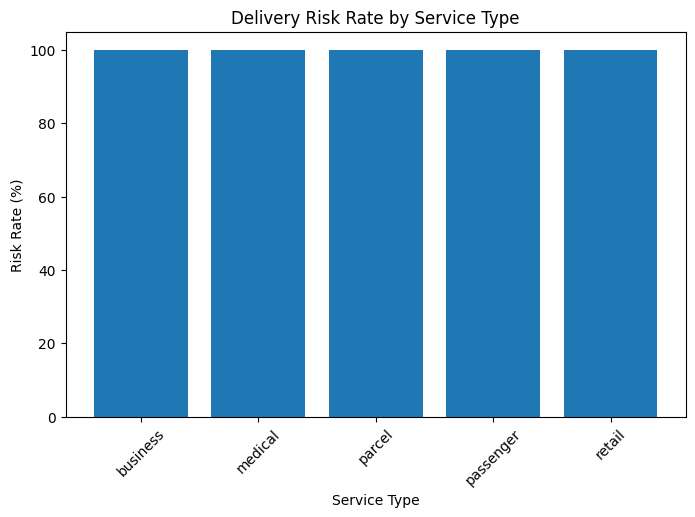

In [13]:
# Bar chart for risk rate by service type
plt.figure(figsize=(8,5))
plt.bar(service_risk_summary["service_type"], service_risk_summary["risk_rate_percent"])
plt.title("Delivery Risk Rate by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Risk Rate (%)")
plt.xticks(rotation=45)
plt.show()

This chart shows which services are more likely to face delivery risk.

13. Visualise average rating by zone

This chart compares customer satisfaction across zones and helps identify weaker operational areas.

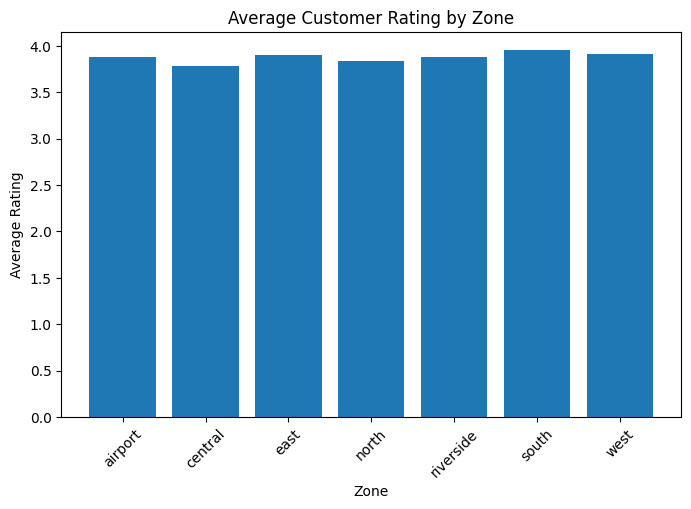

In [14]:
# Bar chart for average rating by zone
plt.figure(figsize=(8,5))
plt.bar(zone_summary["zone"], zone_summary["avg_rating"])
plt.title("Average Customer Rating by Zone")
plt.xlabel("Zone")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

In [16]:
orders_clean.to_csv("orders_clean.csv", index=False)
deliveries_clean.to_csv("deliveries_clean.csv", index=False)
complaints_clean.to_csv("complaints_clean.csv", index=False)
customers_clean.to_csv("customers_clean.csv", index=False)
drivers_clean.to_csv("drivers_clean.csv", index=False)
vehicles_clean.to_csv("vehicles_clean.csv", index=False)
incidents_clean.to_csv("incidents_clean.csv", index=False)
app_events_clean.to_csv("app_events_clean.csv", index=False)
hubs_clean.to_csv("hubs_clean.csv", index=False)

full_analysis.to_csv("full_analysis.csv", index=False)
zone_summary.to_csv("zone_summary.csv", index=False)
service_risk_summary.to_csv("service_risk_summary.csv", index=False)

print("Cleaned and processed datasets exported successfully")

Cleaned and processed datasets exported successfully
